# Mark 3 — Two-Stage Multi-Window Training-ROI and Overfit Gate

## tl;dr

Mark 2 proved that a global prediction-only 3D ROI contains every validation tumor while
reducing the median image area to 42.7%. Mark 3 now performs the minimum training-readiness
work before any full validation training:

1. generate and freeze predicted-liver ROIs for all training patients;
2. verify training tumor containment and geometric round-trip integrity;
3. create source-NIfTI ROI tensors using fixed HU windows;
4. compare broad-only, broad+liver, and broad+liver+narrow inputs on the same 16 slices;
5. authorize only the simplest channel configuration that passes the overfit gate.

This notebook does not access the test split and does not run a full validation experiment.

## Context & Methods

### Key assumptions

- The corrected manifest, Mark 1 checkpoint, and Mark 2 ROI rule are frozen.
- Training ROIs are generated only from predicted-liver probabilities.
- Ground-truth tumor masks score containment and supervise tumor training; they never create ROIs.
- The fixed ROI rule is liver threshold `0.50`, largest 3D component, padding `16`.
- Windows are generated from source NIfTI: broad `[-160,240]`, liver `[-20,140]`,
  and narrow `[20,120]` HU.
- The same 16 training slices are used for every channel ablation.
- Test data remains inaccessible.

### Gates

Training ROI gate:

- minimum tumor-pixel containment ≥99%;
- minimum positive-slice containment ≥99%;
- zero empty training ROIs;
- all crop and inverse-map geometry checks pass.

Overfit gate:

- hard micro-Dice ≥0.90;
- positive predicted-empty rate = 0%;
- finite loss and gradients;
- full-image round-trip Dice ≥0.98;
- no test access.

In [1]:
from __future__ import annotations

from pathlib import Path
from IPython.display import display
import hashlib
import json
import random
import sys
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore", category=FutureWarning)
plt.style.use("seaborn-v0_8-whitegrid")

PROJECT_ROOT = Path(r"D:\DATA SCIENCE AND ANALYTICS\PROJECTS\Liver")
DATASET_ROOT = Path(
    r"D:\DATA SCIENCE AND ANALYTICS\Dataset\Liver\02_staging"
    r"\build_corrected_20260713_214847_v2"
)
MANIFEST_PATH = DATASET_ROOT / "manifests" / "slice_manifest.csv"
CHECKPOINT_PATH = (
    PROJECT_ROOT / "Practice" / "multitask_liver_tumor_outputs" / "multitask_best.pth"
)
MARK2_GATE_PATH = PROJECT_ROOT / "mark 1" / "mark_2_outputs" / "mark_2_gate_result.json"
OUTPUT_DIR = PROJECT_ROOT / "mark 1" / "mark_3_outputs"
ROI_DIR = OUTPUT_DIR / "training_roi_cache"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
ROI_DIR.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

EXPECTED_MANIFEST_SHA256 = (
    "575a6fc391d63dc9bbbbb3317efe4d0f65edd57457ae63c1bfc6c2c615861889"
)
EXPECTED_CHECKPOINT_SHA256 = (
    "9c4160bbd68891f9dc4e5f04ceca4391f38c5869b3f81c72b95d4639e0572223"
)
SEED = 42
ROI_LIVER_THRESHOLD = 0.50
ROI_PADDING = 16
ROI_COMPONENT_MODE = "largest_3d"
ROI_SIZE = 256
LIVER_INFERENCE_BATCH_SIZE = 24
NUM_WORKERS = 0
ORGAN_Z_CLIP = 3.0
WINDOWS = {
    "broad": (-160.0, 240.0),
    "liver": (-20.0, 140.0),
    "narrow": (20.0, 120.0),
}
CHANNEL_CONFIGURATIONS = {
    "broad_1ch": ["broad"],
    "broad_liver_2ch": ["broad", "liver"],
    "broad_liver_narrow_3ch": ["broad", "liver", "narrow"],
}
OVERFIT_SLICES = 16
OVERFIT_BATCH_SIZE = 4
MAX_OVERFIT_EPOCHS = 160
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-5
TUMOR_THRESHOLD = 0.50
OVERFIT_DICE_TARGET = 0.90
ROUNDTRIP_DICE_TARGET = 0.98
RUN_TRAINING_ROI_INFERENCE = True
RUN_OVERFIT_ABLATION = True

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device: {device}")
print(f"Outputs: {OUTPUT_DIR}")

Device: cuda
Outputs: D:\DATA SCIENCE AND ANALYTICS\PROJECTS\Liver\mark 1\mark_3_outputs


## Data

### 1. Verify provenance, Mark 2 authorization, and test lock

In [2]:
from src.framework.data.manifest_dataset import VerifiedManifestDataset
from src.framework.models.mobilenetv2_unet import MobileNetV2UNet

def sha256_file(path, chunk_size=1024 * 1024):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        while chunk := handle.read(chunk_size):
            digest.update(chunk)
    return digest.hexdigest()

assert sha256_file(MANIFEST_PATH) == EXPECTED_MANIFEST_SHA256
assert sha256_file(CHECKPOINT_PATH) == EXPECTED_CHECKPOINT_SHA256
mark2_gate = json.loads(MARK2_GATE_PATH.read_text())
assert mark2_gate["status"] == "mark_2_feasibility_complete"
assert mark2_gate["roi_hard_containment_gate_passed"] is True
assert mark2_gate["roi_efficiency_gate_passed"] is True
assert mark2_gate["test_images_accessed"] is False
selected = mark2_gate["selected_roi_configuration"]
assert float(selected["liver_threshold"]) == ROI_LIVER_THRESHOLD
assert int(selected["padding"]) == ROI_PADDING
assert selected["component_mode"] == ROI_COMPONENT_MODE

manifest = pd.read_csv(MANIFEST_PATH)
train_manifest = (
    manifest.loc[manifest["split"].eq("train")]
    .sort_values(["volume_id", "slice_index"])
    .reset_index(drop=True)
)
assert len(train_manifest) == 40_667
assert train_manifest["volume_id"].nunique() == 104
try:
    VerifiedManifestDataset(MANIFEST_PATH, split="test", root_dir=DATASET_ROOT)
except PermissionError:
    pass
else:
    raise AssertionError("STOP: test split opened without authorization.")

provenance = {
    "manifest_sha256": EXPECTED_MANIFEST_SHA256,
    "liver_checkpoint_sha256": EXPECTED_CHECKPOINT_SHA256,
    "mark2_gate_path": str(MARK2_GATE_PATH),
    "training_slices": int(len(train_manifest)),
    "training_patients": int(train_manifest["volume_id"].nunique()),
    "roi_rule": {
        "liver_threshold": ROI_LIVER_THRESHOLD,
        "padding": ROI_PADDING,
        "component_mode": ROI_COMPONENT_MODE,
    },
    "windows": {key: list(value) for key, value in WINDOWS.items()},
    "roi_uses_ground_truth": False,
    "test_images_accessed": False,
}
(OUTPUT_DIR / "mark_3_provenance.json").write_text(
    json.dumps(provenance, indent=2), encoding="utf-8"
)
print("PASS: provenance, Mark 2 authorization, and test lock verified.")

PASS: provenance, Mark 2 authorization, and test lock verified.


### 2. Load the frozen liver model and reproduce its input normalization

In [3]:
checkpoint = torch.load(CHECKPOINT_PATH, map_location="cpu", weights_only=False)
assert checkpoint["epoch"] == 8
assert checkpoint["manifest_sha256"] == EXPECTED_MANIFEST_SHA256
liver_model = MobileNetV2UNet(in_channels=1, out_channels=2, pretrained=False)
liver_model.load_state_dict(checkpoint["model_state"], strict=True)
liver_model.to(device).eval()

def image_robust_normalize(image):
    image = np.asarray(image, dtype=np.float32)
    reference = image[image > 0]
    if reference.size < 32:
        reference = image.reshape(-1)
    center = float(np.median(reference))
    q25, q75 = np.percentile(reference, [25, 75])
    robust_sigma = float((q75 - q25) / 1.349)
    if not np.isfinite(robust_sigma) or robust_sigma < 1e-3:
        robust_sigma = max(float(np.std(reference)), 1e-3)
    normalized = np.clip(
        (image - center) / robust_sigma, -ORGAN_Z_CLIP, ORGAN_Z_CLIP
    )
    return ((normalized + ORGAN_Z_CLIP) / (2 * ORGAN_Z_CLIP)).astype(np.float32)

with torch.inference_mode():
    probe = liver_model(torch.zeros(1, 1, 256, 256, device=device))
assert probe.shape == (1, 2, 256, 256)
print("PASS: strict frozen liver model loaded.")

PASS: strict frozen liver model loaded.


### 3. Generate prediction-only training ROIs

Probability masks are accumulated for one patient at a time, converted to the largest 3D
component, and immediately reduced to one padded 3D-projected box. Full probability volumes
are not retained.

In [4]:
from scipy import ndimage

def load_normalized_png(path):
    with Image.open(path) as handle:
        image = np.asarray(handle.convert("L"), dtype=np.float32) / 255.0
    return image_robust_normalize(image)

def largest_component(mask):
    labels, count = ndimage.label(mask, structure=np.ones((3, 3, 3), dtype=np.uint8))
    if count == 0:
        return mask
    sizes = np.bincount(labels.ravel())
    sizes[0] = 0
    return labels == sizes.argmax()

def padded_bbox(mask, padding):
    if not mask.any():
        return None
    _, ys, xs = np.where(mask)
    return (
        max(int(ys.min()) - padding, 0),
        min(int(ys.max()) + 1 + padding, 256),
        max(int(xs.min()) - padding, 0),
        min(int(xs.max()) + 1 + padding, 256),
    )

def predict_volume_liver(group):
    probabilities = []
    paths = [DATASET_ROOT / path for path in group["image_path"]]
    with torch.inference_mode():
        for start in range(0, len(paths), LIVER_INFERENCE_BATCH_SIZE):
            images = np.stack([
                load_normalized_png(path)
                for path in paths[start:start + LIVER_INFERENCE_BATCH_SIZE]
            ])
            batch = torch.from_numpy(images[:, None]).float().to(device)
            probabilities.append(torch.sigmoid(liver_model(batch))[:, 0].cpu().numpy())
    return np.concatenate(probabilities, axis=0)

def score_box(group, box):
    tumor_total = tumor_inside = positive_total = positive_inside = 0
    for row in group.itertuples(index=False):
        with Image.open(DATASET_ROOT / row.tumor_mask_path) as handle:
            tumor = np.asarray(handle.convert("L"), dtype=np.uint8) > 0
        tumor_pixels = int(tumor.sum())
        tumor_total += tumor_pixels
        if tumor_pixels:
            positive_total += 1
        if box is not None:
            y0, y1, x0, x1 = box
            inside = int(tumor[y0:y1, x0:x1].sum())
            tumor_inside += inside
            positive_inside += int(tumor_pixels > 0 and inside > 0)
    return {
        "tumor_pixel_containment": tumor_inside / tumor_total if tumor_total else np.nan,
        "positive_slice_containment": positive_inside / positive_total if positive_total else np.nan,
        "tumor_pixels": tumor_total,
        "positive_slices": positive_total,
    }

roi_path = OUTPUT_DIR / "training_roi_manifest.csv"
if RUN_TRAINING_ROI_INFERENCE or not roi_path.is_file():
    roi_rows = []
    for number, (volume_id, group) in enumerate(
        train_manifest.groupby("volume_id", sort=True), start=1
    ):
        probabilities = predict_volume_liver(group)
        liver_mask = largest_component(probabilities >= ROI_LIVER_THRESHOLD)
        box = padded_bbox(liver_mask, ROI_PADDING)
        scores = score_box(group, box)
        roi_rows.append({
            "volume_id": int(volume_id),
            "roi_empty": box is None,
            "y0": box[0] if box else np.nan,
            "y1": box[1] if box else np.nan,
            "x0": box[2] if box else np.nan,
            "x1": box[3] if box else np.nan,
            "crop_area_ratio": (
                ((box[1]-box[0]) * (box[3]-box[2])) / (256*256)
                if box else 0.0
            ),
            **scores,
        })
        if number % 10 == 0 or number == 104:
            print(f"ROI patients processed: {number}/104")
    training_rois = pd.DataFrame(roi_rows)
    training_rois.to_csv(roi_path, index=False)
else:
    training_rois = pd.read_csv(roi_path)

display(training_rois.describe(include="all"))

ROI patients processed: 10/104
ROI patients processed: 20/104
ROI patients processed: 30/104
ROI patients processed: 40/104
ROI patients processed: 50/104
ROI patients processed: 60/104
ROI patients processed: 70/104
ROI patients processed: 80/104
ROI patients processed: 90/104
ROI patients processed: 100/104
ROI patients processed: 104/104


,volume_id,roi_empty,y0,y1,x0,x1,crop_area_ratio,tumor_pixel_containment,positive_slice_containment,tumor_pixels,positive_slices
count,104.000000,104,104.000000,104.000000,104.000000,104.000000,104.000000,96.0,96.0,104.000000,104.000000
unique,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,104,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,51.500000,NaN,32.913462,206.538462,55.432692,211.307692,0.415163,1.0,1.0,24898.682692,47.403846
std,30.166206,NaN,26.313683,30.419374,13.427088,15.593798,0.077756,0.0,0.0,61054.906934,56.451288
min,0.000000,NaN,0.000000,156.000000,15.000000,166.000000,0.205261,1.0,1.0,0.000000,0.000000
25%,25.750000,NaN,11.000000,180.000000,46.000000,201.750000,0.373051,1.0,1.0,645.500000,10.000000
50%,51.500000,NaN,23.500000,198.500000,58.000000,212.000000,0.420425,1.0,1.0,3080.000000,25.000000
75%,77.250000,NaN,58.250000,237.250000,64.000000,222.250000,0.462467,1.0,1.0,13571.750000,63.250000


### 4. Apply the training ROI gate and visualize coverage

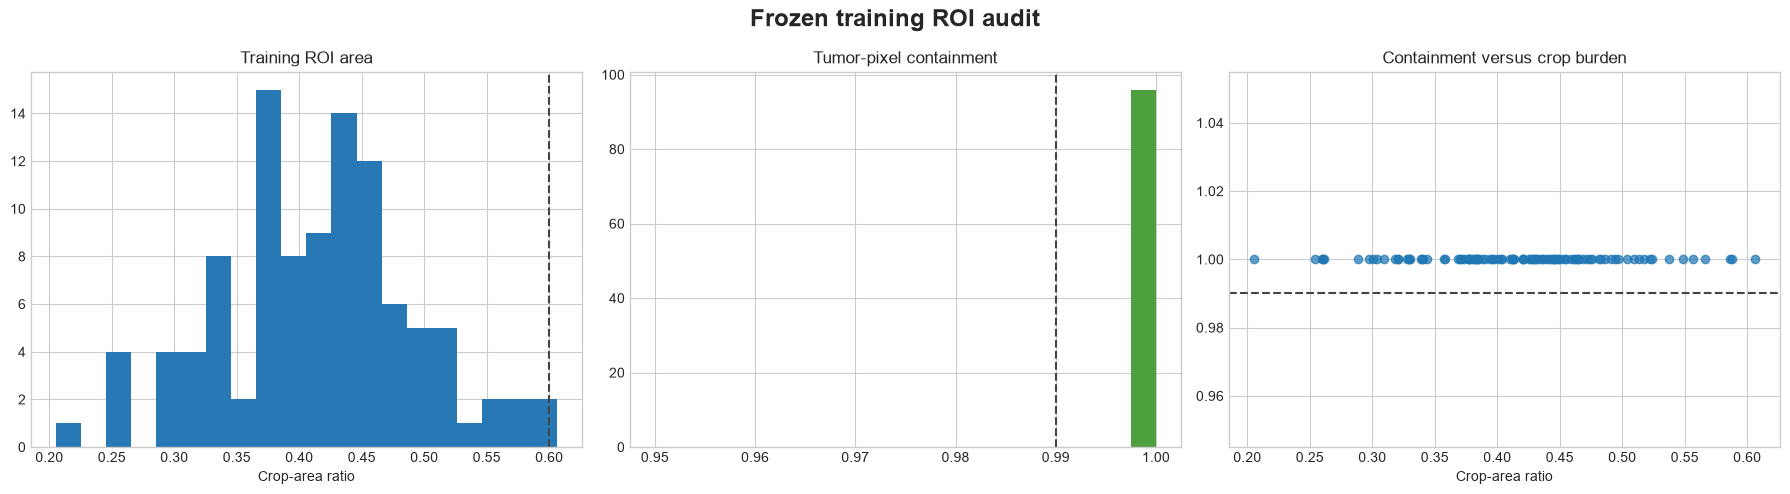

,value
minimum_tumor_pixel_containment,1.0
minimum_positive_slice_containment,1.0
empty_training_rois,0
median_crop_area_ratio,0.420425
maximum_crop_area_ratio,0.606201
passed,True


In [5]:
positive_roi_patients = training_rois.loc[training_rois["tumor_pixels"].gt(0)]
training_roi_gate = {
    "minimum_tumor_pixel_containment": float(
        positive_roi_patients["tumor_pixel_containment"].min()
    ),
    "minimum_positive_slice_containment": float(
        positive_roi_patients["positive_slice_containment"].min()
    ),
    "empty_training_rois": int(training_rois["roi_empty"].sum()),
    "median_crop_area_ratio": float(training_rois["crop_area_ratio"].median()),
    "maximum_crop_area_ratio": float(training_rois["crop_area_ratio"].max()),
}
training_roi_gate["passed"] = bool(
    training_roi_gate["minimum_tumor_pixel_containment"] >= 0.99
    and training_roi_gate["minimum_positive_slice_containment"] >= 0.99
    and training_roi_gate["empty_training_rois"] == 0
)
(OUTPUT_DIR / "training_roi_gate.json").write_text(
    json.dumps(training_roi_gate, indent=2), encoding="utf-8"
)

figure, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].hist(training_rois["crop_area_ratio"], bins=20, color="#2878B5")
axes[0].axvline(0.60, linestyle="--", color="#444444")
axes[0].set_title("Training ROI area")
axes[0].set_xlabel("Crop-area ratio")
axes[1].hist(
    positive_roi_patients["tumor_pixel_containment"],
    bins=np.linspace(0.95, 1.0, 21), color="#4E9F3D",
)
axes[1].axvline(0.99, linestyle="--", color="#444444")
axes[1].set_title("Tumor-pixel containment")
axes[2].scatter(
    training_rois["crop_area_ratio"],
    training_rois["tumor_pixel_containment"].fillna(1.0),
    alpha=0.7,
)
axes[2].axhline(0.99, linestyle="--", color="#444444")
axes[2].set_title("Containment versus crop burden")
axes[2].set_xlabel("Crop-area ratio")
figure.suptitle("Frozen training ROI audit", fontsize=17, weight="bold")
figure.tight_layout()
figure.savefig(OUTPUT_DIR / "training_roi_audit.png", dpi=170, bbox_inches="tight")
plt.show()
display(pd.DataFrame([training_roi_gate]).T.rename(columns={0: "value"}))
assert training_roi_gate["passed"], "STOP: training ROI gate failed."

### 5. Select the fixed 16-slice training cohort

In [6]:
positive = train_manifest.loc[train_manifest["tumor_pixels"].gt(0)].copy()
positive["size_quartile"] = pd.qcut(
    positive["tumor_pixels"], 4, labels=["Q1", "Q2", "Q3", "Q4"]
)
rng = np.random.default_rng(SEED)
selected_rows = []
used_patients = set()
for quartile in ["Q1", "Q2", "Q3", "Q4"]:
    candidates = positive.loc[positive["size_quartile"].eq(quartile)].copy()
    candidates = candidates.sample(frac=1.0, random_state=SEED)
    chosen = []
    for row in candidates.itertuples(index=False):
        if row.volume_id not in used_patients or len(chosen) >= 3:
            chosen.append(row)
            used_patients.add(row.volume_id)
        if len(chosen) == 4:
            break
    selected_rows.extend(chosen)

selected_frame = pd.DataFrame([row._asdict() for row in selected_rows])
assert len(selected_frame) == OVERFIT_SLICES
assert selected_frame["volume_id"].nunique() >= 8
selected_frame.to_csv(OUTPUT_DIR / "overfit_selected_slices.csv", index=False)
display(selected_frame[[
    "sample_id", "volume_id", "slice_index", "tumor_pixels", "size_quartile"
]])

,sample_id,volume_id,slice_index,tumor_pixels,size_quartile
0,v084_s0632,84,632,18,Q1
1,v049_s0158,49,158,41,Q1
2,v037_s0092,37,92,42,Q1
3,v008_s0391,8,391,40,Q1
4,v066_s0078,66,78,179,Q2
5,v033_s0049,33,49,189,Q2
6,v029_s0058,29,58,67,Q2
7,v007_s0365,7,365,194,Q2
8,v088_s0432,88,432,699,Q3
9,v056_s0150,56,150,537,Q3


### 6. Build source-HU ROI tensors and verify inverse mapping

In [7]:
import nibabel as nib

roi_index = training_rois.set_index("volume_id")
volume_cache = {}

def window_image(hu, lower, upper):
    return np.clip((hu - lower) / (upper - lower), 0.0, 1.0).astype(np.float32)

def resize_float(array, size=(ROI_SIZE, ROI_SIZE)):
    return np.asarray(
        Image.fromarray(array.astype(np.float32), mode="F").resize(
            size, Image.Resampling.BILINEAR
        ),
        dtype=np.float32,
    )

def resize_mask(array, size=(ROI_SIZE, ROI_SIZE)):
    return np.asarray(
        Image.fromarray(array.astype(np.uint8) * 255).resize(
            size, Image.Resampling.NEAREST
        ),
        dtype=np.uint8,
    ) > 0

def source_hu_slice(row):
    volume_id = int(row.volume_id)
    if volume_id not in volume_cache:
        volume_cache[volume_id] = nib.load(str(row.source_volume_path))
    return np.asanyarray(
        volume_cache[volume_id].dataobj[:, :, int(row.slice_index)]
    ).astype(np.float32)

tensors = {name: [] for name in CHANNEL_CONFIGURATIONS}
targets = []
roundtrip_rows = []
preview_rows = []
for row in selected_frame.itertuples(index=False):
    box_row = roi_index.loc[int(row.volume_id)]
    y0, y1, x0, x1 = [int(box_row[key]) for key in ("y0", "y1", "x0", "x1")]
    hu_native = source_hu_slice(row)
    channels_256 = {
        name: resize_float(window_image(hu_native, lower, upper))
        for name, (lower, upper) in WINDOWS.items()
    }
    with Image.open(DATASET_ROOT / row.tumor_mask_path) as handle:
        tumor_full = np.asarray(handle.convert("L"), dtype=np.uint8) > 0
    target_roi = resize_mask(tumor_full[y0:y1, x0:x1])
    targets.append(target_roi[None].astype(np.float32))

    for config_name, channel_names in CHANNEL_CONFIGURATIONS.items():
        crop_channels = [
            resize_float(channels_256[name][y0:y1, x0:x1])
            for name in channel_names
        ]
        tensors[config_name].append(np.stack(crop_channels))

    restored_crop = resize_mask(
        target_roi, size=(x1 - x0, y1 - y0)
    )
    restored = np.zeros((256, 256), dtype=bool)
    restored[y0:y1, x0:x1] = restored_crop
    intersection = int((restored & tumor_full).sum())
    roundtrip_dice = (
        (2 * intersection + 1e-6)
        / (restored.sum() + tumor_full.sum() + 1e-6)
    )
    roundtrip_rows.append({
        "sample_id": row.sample_id,
        "volume_id": int(row.volume_id),
        "roundtrip_dice": float(roundtrip_dice),
        "box": [y0, y1, x0, x1],
    })
    preview_rows.append((row, channels_256, tumor_full, (y0, y1, x0, x1)))

targets = torch.from_numpy(np.stack(targets)).float()
tensors = {
    name: torch.from_numpy(np.stack(values)).float()
    for name, values in tensors.items()
}
roundtrip_metrics = pd.DataFrame(roundtrip_rows)
roundtrip_metrics.to_csv(OUTPUT_DIR / "roundtrip_geometry_metrics.csv", index=False)
assert roundtrip_metrics["roundtrip_dice"].min() >= ROUNDTRIP_DICE_TARGET
for name, values in tensors.items():
    assert values.shape[0] == OVERFIT_SLICES
    assert values.shape[2:] == (ROI_SIZE, ROI_SIZE)
    assert torch.isfinite(values).all()
print("PASS: ROI tensors and full-image round-trip geometry verified.")

PASS: ROI tensors and full-image round-trip geometry verified.


### 7. Visualize fixed windows, ROI crops, and targets

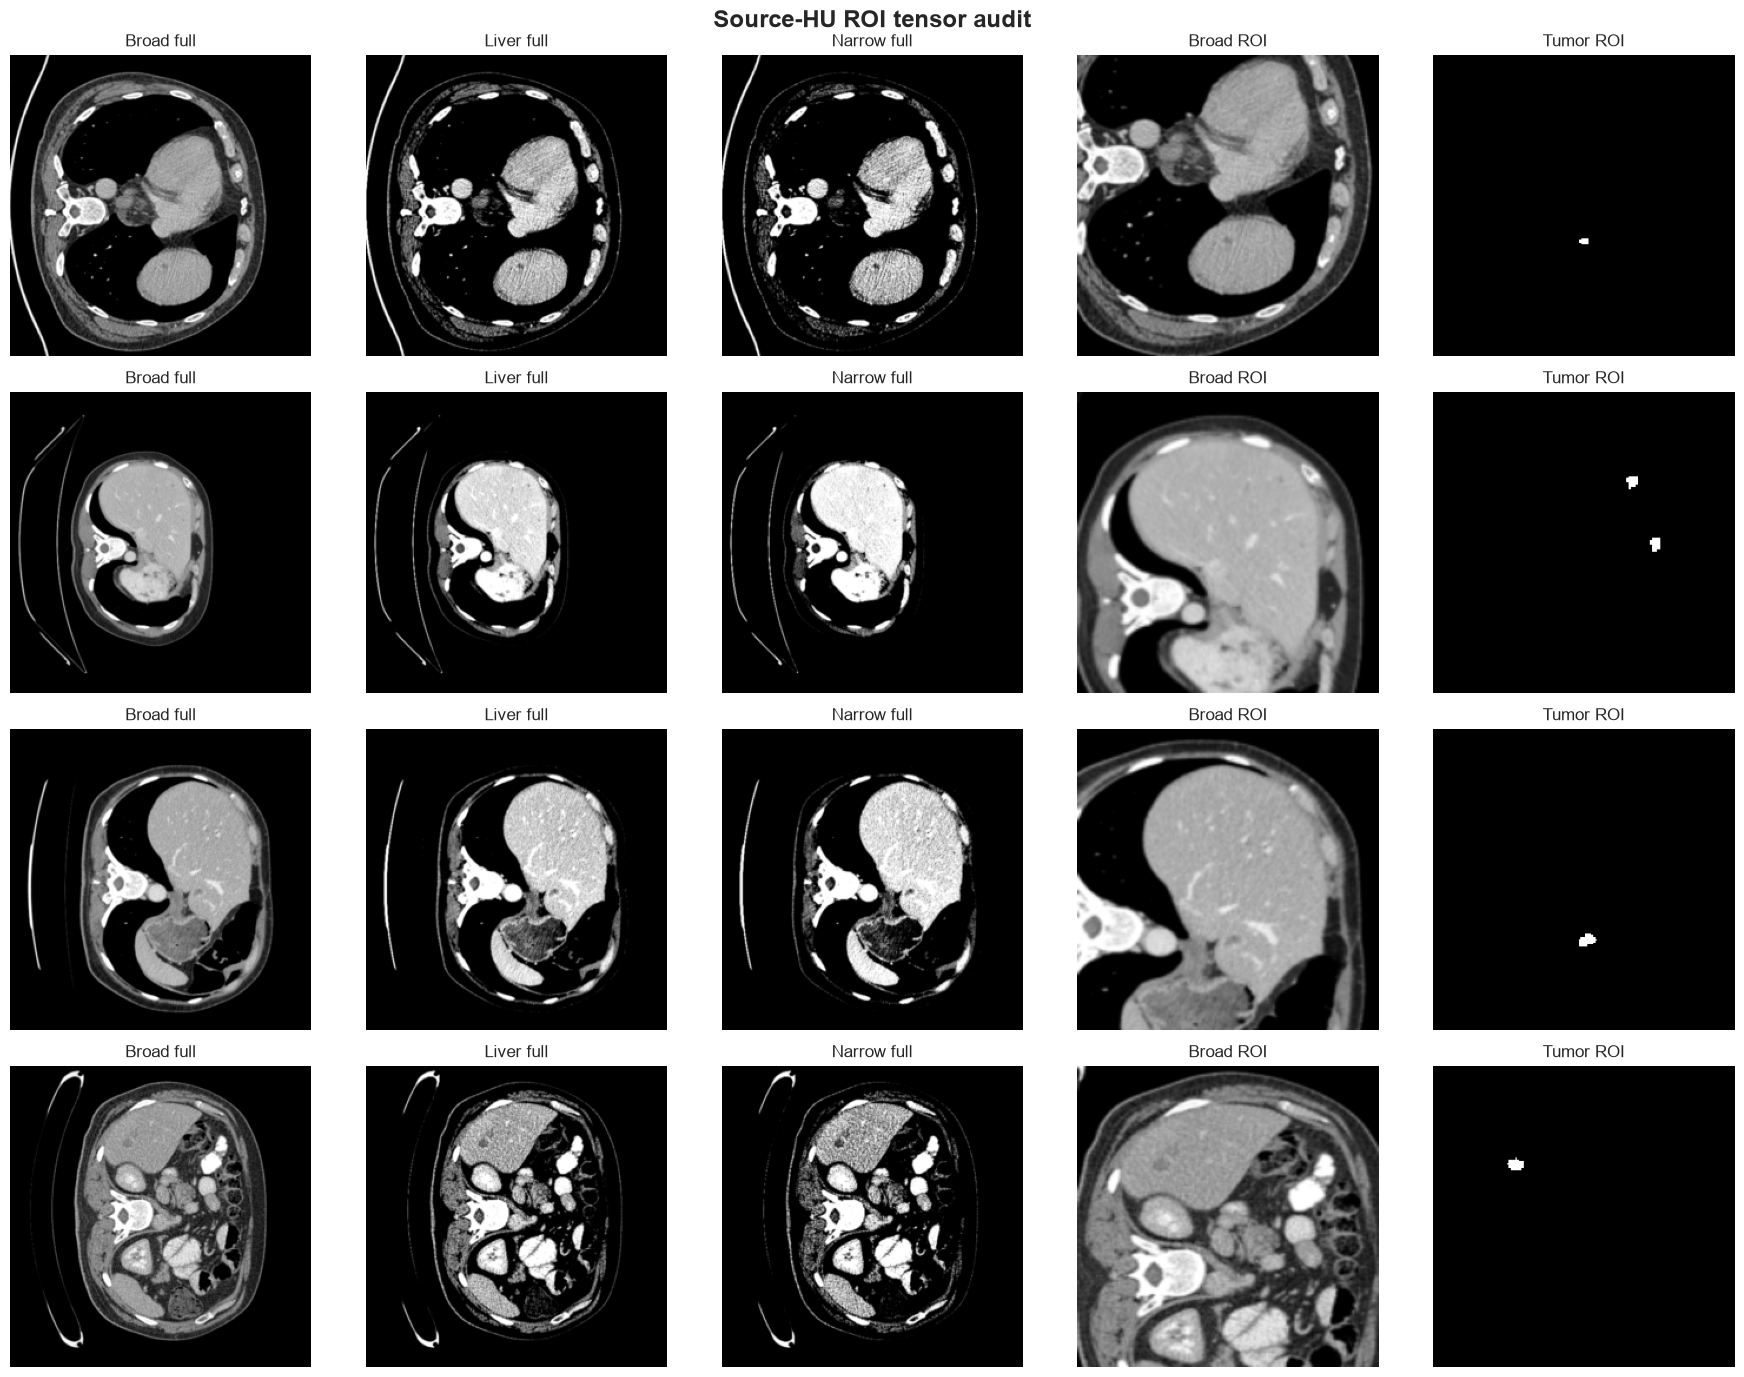

In [8]:
figure, axes = plt.subplots(4, 5, figsize=(18, 14))
for row_axes, (row, channels, tumor, box) in zip(axes, preview_rows[:4]):
    y0, y1, x0, x1 = box
    panels = [
        (channels["broad"], "Broad full"),
        (channels["liver"], "Liver full"),
        (channels["narrow"], "Narrow full"),
        (resize_float(channels["broad"][y0:y1, x0:x1]), "Broad ROI"),
        (resize_mask(tumor[y0:y1, x0:x1]), "Tumor ROI"),
    ]
    for axis, (panel, title) in zip(row_axes, panels):
        axis.imshow(panel, cmap="gray", vmin=0, vmax=1)
        axis.set_title(title)
        axis.axis("off")
    row_axes[0].set_ylabel(
        f"{row.sample_id}\n{row.size_quartile}", fontsize=9
    )
figure.suptitle("Source-HU ROI tensor audit", fontsize=17, weight="bold")
figure.tight_layout()
figure.savefig(OUTPUT_DIR / "roi_tensor_audit.png", dpi=170, bbox_inches="tight")
plt.show()

## Training

### 8. Define warm start, stable loss, and overfit metrics

In [9]:
from src.framework.losses.focal_dice import FocalDiceLoss

source_state = checkpoint["model_state"]
loss_function = FocalDiceLoss(
    focal_alpha=0.75, focal_gamma=2.0, focal_weight=0.5, dice_weight=0.5
)

def build_tumor_model(in_channels):
    model = MobileNetV2UNet(
        in_channels=in_channels, out_channels=1, pretrained=False
    )
    target_state = model.state_dict()
    for key, value in source_state.items():
        if key in target_state and target_state[key].shape == value.shape:
            target_state[key] = value.clone()
    source_first = source_state["enc_0.0.weight"]
    target_state["enc_0.0.weight"] = source_first.repeat(
        1, in_channels, 1, 1
    ) / in_channels
    target_state["final.weight"] = source_state["final.weight"][1:2].clone()
    target_state["final.bias"] = source_state["final.bias"][1:2].clone()
    model.load_state_dict(target_state, strict=True)
    return model.to(device)

def freeze_batchnorm_running_stats(model):
    for module in model.modules():
        if isinstance(module, nn.BatchNorm2d):
            module.eval()

def hard_metrics(logits, truth):
    prediction = torch.sigmoid(logits) >= TUMOR_THRESHOLD
    target = truth >= 0.5
    intersection = int((prediction & target).sum())
    predicted = int(prediction.sum())
    true = int(target.sum())
    dice = (2 * intersection + 1e-6) / (predicted + true + 1e-6)
    pred_per_slice = prediction.sum(dim=(1, 2, 3))
    true_per_slice = target.sum(dim=(1, 2, 3))
    positive_empty = int(((true_per_slice > 0) & (pred_per_slice == 0)).sum())
    return {
        "hard_micro_dice": float(dice),
        "positive_predicted_empty_pct": 100 * positive_empty / len(truth),
    }

### 9. Run the controlled 1/2/3-channel overfit ablation

In [10]:
histories = []
final_metrics = []
trained_models = {}

if RUN_OVERFIT_ABLATION:
    for config_name, input_tensor in tensors.items():
        print(f"\n=== {config_name} ===")
        model = build_tumor_model(input_tensor.shape[1])
        optimizer = torch.optim.AdamW(
            model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
        )
        loader_generator = torch.Generator().manual_seed(SEED)
        loader = DataLoader(
            TensorDataset(input_tensor, targets),
            batch_size=OVERFIT_BATCH_SIZE,
            shuffle=True,
            generator=loader_generator,
            num_workers=0,
        )
        best_dice = 0.0
        for epoch in range(1, MAX_OVERFIT_EPOCHS + 1):
            model.train()
            freeze_batchnorm_running_stats(model)
            epoch_loss = 0.0
            gradient_finite = True
            for images, truth in loader:
                images, truth = images.to(device), truth.to(device)
                optimizer.zero_grad(set_to_none=True)
                logits = model(images)
                loss = loss_function(logits, truth)
                if not torch.isfinite(loss):
                    raise FloatingPointError(
                        f"Non-finite loss for {config_name} epoch {epoch}"
                    )
                loss.backward()
                gradient_finite &= all(
                    parameter.grad is None or torch.isfinite(parameter.grad).all()
                    for parameter in model.parameters()
                )
                if not gradient_finite:
                    raise FloatingPointError("Non-finite gradient.")
                torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                optimizer.step()
                epoch_loss += float(loss) * len(images)

            model.eval()
            with torch.inference_mode():
                logits = model(input_tensor.to(device))
                metrics = hard_metrics(logits, targets.to(device))
            record = {
                "configuration": config_name,
                "channels": int(input_tensor.shape[1]),
                "epoch": epoch,
                "loss": epoch_loss / len(input_tensor),
                "gradient_finite": gradient_finite,
                **metrics,
            }
            histories.append(record)
            best_dice = max(best_dice, metrics["hard_micro_dice"])
            if epoch == 1 or epoch % 10 == 0:
                print(
                    f"epoch={epoch:03d} loss={record['loss']:.4f} "
                    f"dice={record['hard_micro_dice']:.4f} "
                    f"empty={record['positive_predicted_empty_pct']:.1f}%"
                )
            if (
                metrics["hard_micro_dice"] >= OVERFIT_DICE_TARGET
                and metrics["positive_predicted_empty_pct"] == 0
            ):
                break

        trained_models[config_name] = model.cpu()
        final_metrics.append({
            "configuration": config_name,
            "channels": int(input_tensor.shape[1]),
            "epochs_completed": epoch,
            "best_hard_micro_dice": best_dice,
            "final_hard_micro_dice": metrics["hard_micro_dice"],
            "positive_predicted_empty_pct": metrics[
                "positive_predicted_empty_pct"
            ],
            "passed": bool(
                metrics["hard_micro_dice"] >= OVERFIT_DICE_TARGET
                and metrics["positive_predicted_empty_pct"] == 0
            ),
        })
        torch.save(
            {
                "model_state": model.state_dict(),
                "configuration": config_name,
                "channels": CHANNEL_CONFIGURATIONS[config_name],
                "manifest_sha256": EXPECTED_MANIFEST_SHA256,
                "source_checkpoint_sha256": EXPECTED_CHECKPOINT_SHA256,
            },
            OUTPUT_DIR / f"{config_name}_overfit.pth",
        )

history_frame = pd.DataFrame(histories)
comparison = pd.DataFrame(final_metrics)
history_frame.to_csv(OUTPUT_DIR / "overfit_history.csv", index=False)
comparison.to_csv(OUTPUT_DIR / "overfit_channel_comparison.csv", index=False)
display(comparison)


=== broad_1ch ===
epoch=001 loss=0.3344 dice=0.6650 empty=12.5%
epoch=010 loss=0.1424 dice=0.8062 empty=6.2%

=== broad_liver_2ch ===
epoch=001 loss=0.5015 dice=0.5846 empty=6.2%
epoch=010 loss=0.1402 dice=0.8016 empty=0.0%
epoch=020 loss=0.0617 dice=0.9039 empty=0.0%

=== broad_liver_narrow_3ch ===
epoch=001 loss=0.6734 dice=0.0185 empty=68.8%
epoch=010 loss=0.2871 dice=0.5803 empty=0.0%
epoch=020 loss=0.1771 dice=0.7327 empty=0.0%
epoch=030 loss=0.0904 dice=0.8262 empty=0.0%
epoch=040 loss=0.0625 dice=0.8965 empty=0.0%


,configuration,channels,epochs_completed,best_hard_micro_dice,final_hard_micro_dice,positive_predicted_empty_pct,passed
0,broad_1ch,1,17,0.900557,0.900557,0.0,True
1,broad_liver_2ch,2,20,0.903859,0.903859,0.0,True
2,broad_liver_narrow_3ch,3,42,0.900470,0.900470,0.0,True


### 10. Visualize convergence and select the simplest passing input

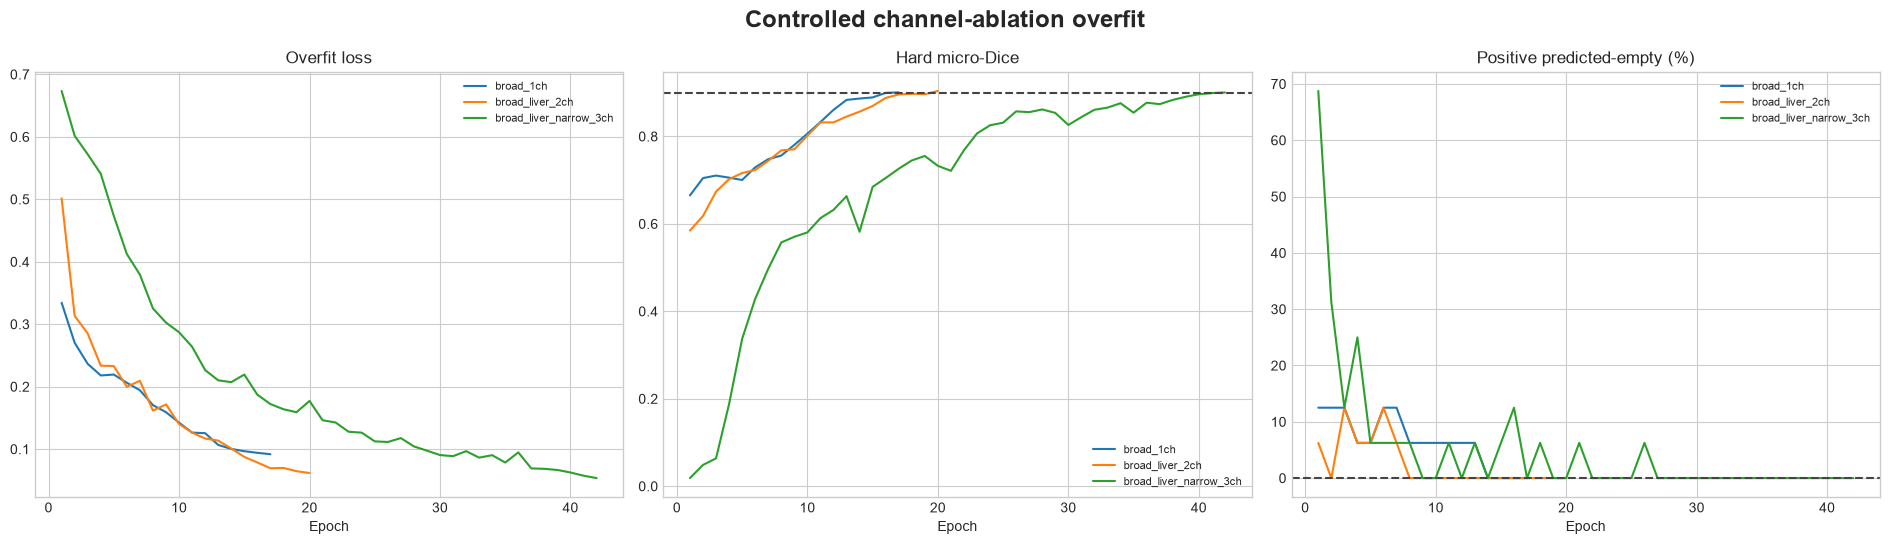

Selected: {'configuration': 'broad_1ch', 'channels': 1, 'epochs_completed': 17, 'best_hard_micro_dice': 0.9005570034263234, 'final_hard_micro_dice': 0.9005570034263234, 'positive_predicted_empty_pct': 0.0, 'passed': True}


In [11]:
passing = comparison.loc[comparison["passed"]].sort_values(
    ["channels", "epochs_completed", "final_hard_micro_dice"],
    ascending=[True, True, False],
)
selected_configuration = (
    passing.iloc[0] if not passing.empty else
    comparison.sort_values("best_hard_micro_dice", ascending=False).iloc[0]
)

figure, axes = plt.subplots(1, 3, figsize=(19, 5.5))
for name, group in history_frame.groupby("configuration"):
    axes[0].plot(group["epoch"], group["loss"], label=name)
    axes[1].plot(group["epoch"], group["hard_micro_dice"], label=name)
    axes[2].plot(
        group["epoch"], group["positive_predicted_empty_pct"], label=name
    )
axes[0].set_title("Overfit loss")
axes[1].axhline(OVERFIT_DICE_TARGET, linestyle="--", color="#444444")
axes[1].set_title("Hard micro-Dice")
axes[2].axhline(0, linestyle="--", color="#444444")
axes[2].set_title("Positive predicted-empty (%)")
for axis in axes:
    axis.set_xlabel("Epoch")
    axis.legend(fontsize=8)
figure.suptitle("Controlled channel-ablation overfit", fontsize=17, weight="bold")
figure.tight_layout()
figure.savefig(OUTPUT_DIR / "overfit_convergence_dashboard.png",
               dpi=170, bbox_inches="tight")
plt.show()
print("Selected:", selected_configuration.to_dict())

### 11. Inspect expected and generated ROI masks

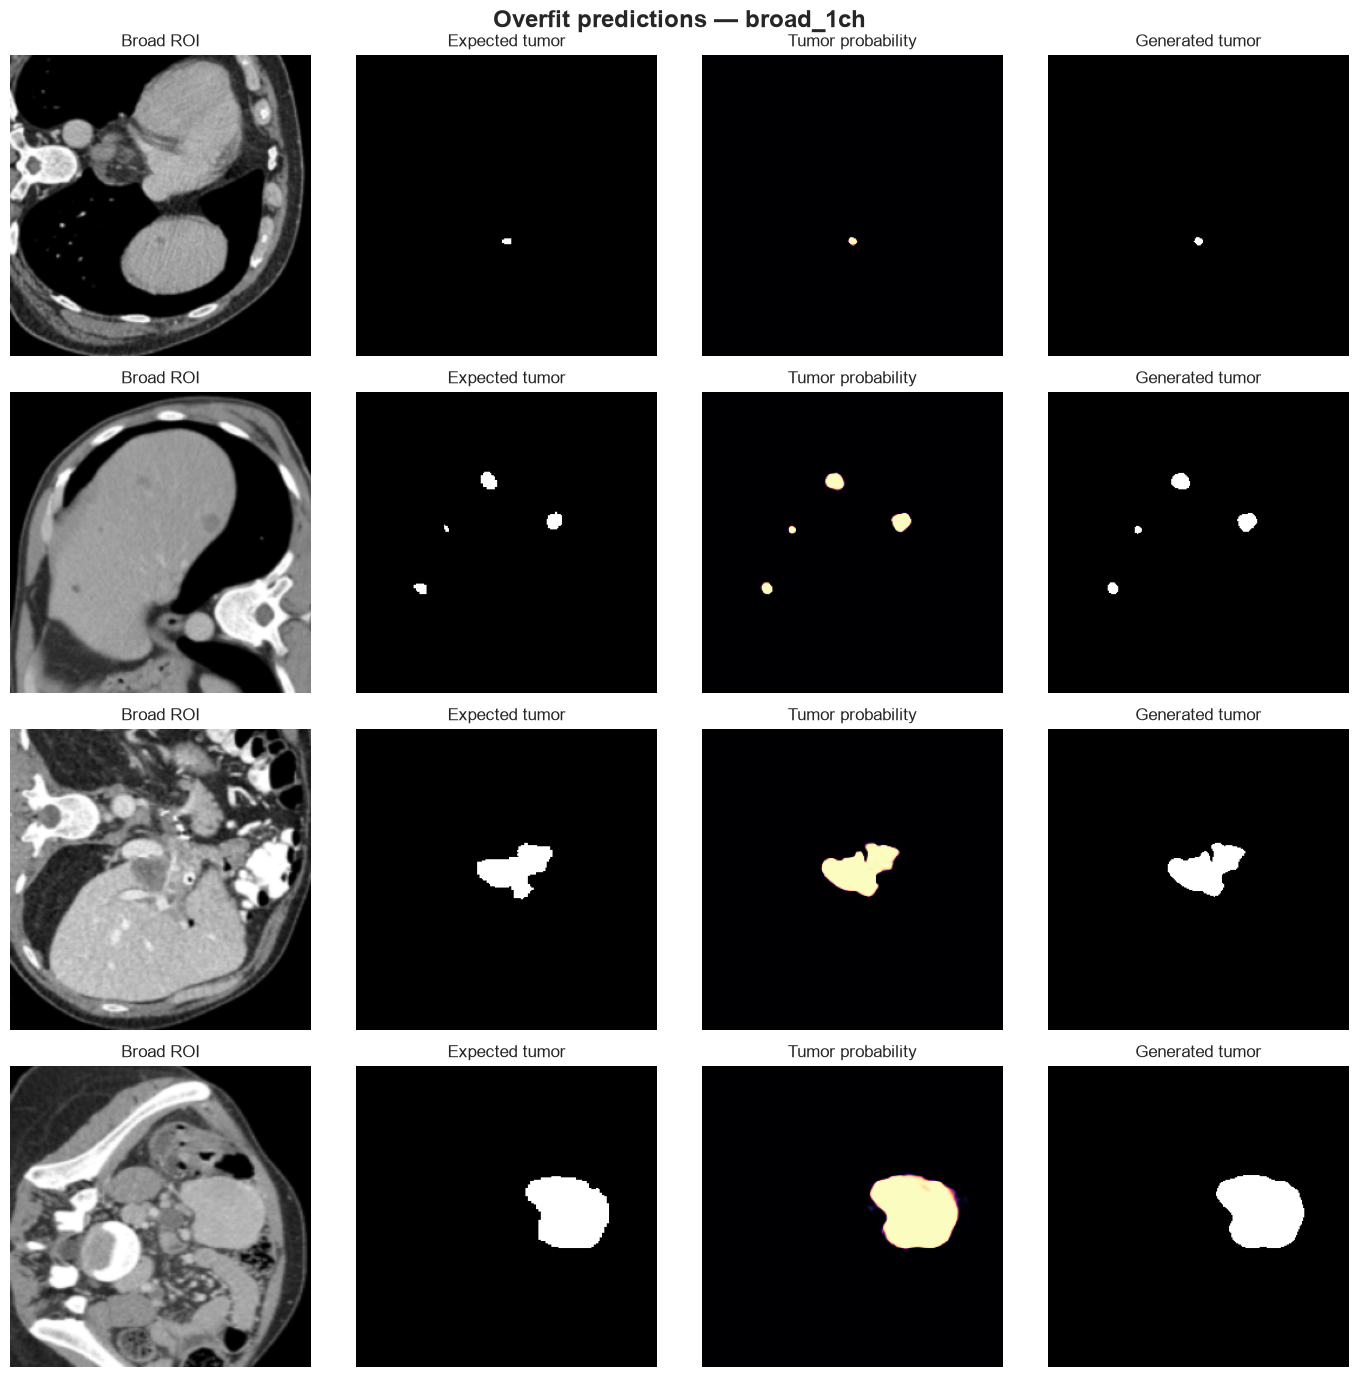

In [12]:
selected_name = selected_configuration["configuration"]
selected_model = trained_models[selected_name].to(device).eval()
selected_inputs = tensors[selected_name].to(device)
with torch.inference_mode():
    selected_probabilities = torch.sigmoid(selected_model(selected_inputs)).cpu()
predictions = selected_probabilities >= TUMOR_THRESHOLD

figure, axes = plt.subplots(4, 4, figsize=(14, 14))
review_indices = [0, 4, 8, 12]
for row_axes, index in zip(axes, review_indices):
    panels = [
        (selected_inputs[index, 0].cpu(), "Broad ROI"),
        (targets[index, 0], "Expected tumor"),
        (selected_probabilities[index, 0], "Tumor probability"),
        (predictions[index, 0], "Generated tumor"),
    ]
    for axis, (panel, title) in zip(row_axes, panels):
        axis.imshow(panel, cmap="magma" if "probability" in title else "gray",
                    vmin=0, vmax=1)
        axis.set_title(title)
        axis.axis("off")
    row_axes[0].set_ylabel(selected_frame.iloc[index]["sample_id"], fontsize=8)
figure.suptitle(
    f"Overfit predictions — {selected_name}", fontsize=17, weight="bold"
)
figure.tight_layout()
figure.savefig(OUTPUT_DIR / "overfit_prediction_review.png",
               dpi=170, bbox_inches="tight")
plt.show()

## Takeaways

### 12. Write the Mark 3 gate and next action

In [13]:
overfit_passed = bool(selected_configuration["passed"])
geometry_passed = bool(
    roundtrip_metrics["roundtrip_dice"].min() >= ROUNDTRIP_DICE_TARGET
)
full_gate_passed = bool(
    training_roi_gate["passed"] and overfit_passed and geometry_passed
)
gate_result = {
    "status": (
        "mark_3_overfit_pass" if full_gate_passed else "mark_3_overfit_fail"
    ),
    "training_roi_gate_passed": bool(training_roi_gate["passed"]),
    "overfit_gate_passed": overfit_passed,
    "geometry_gate_passed": geometry_passed,
    "selected_configuration": selected_configuration.to_dict(),
    "selected_channels": CHANNEL_CONFIGURATIONS[
        selected_configuration["configuration"]
    ],
    "minimum_training_tumor_containment": training_roi_gate[
        "minimum_tumor_pixel_containment"
    ],
    "minimum_roundtrip_dice": float(roundtrip_metrics["roundtrip_dice"].min()),
    "manifest_sha256": EXPECTED_MANIFEST_SHA256,
    "source_checkpoint_sha256": EXPECTED_CHECKPOINT_SHA256,
    "test_images_accessed": False,
    "decision": (
        "PROCEED_TO_3_TO_5_EPOCH_TWO_STAGE_VALIDATION_SMOKE"
        if full_gate_passed else
        "STOP_AND_REPAIR_ROI_GEOMETRY_OR_INPUT_REPRESENTATION"
    ),
    "next_notebook": (
        "mark_4_two_stage_validation_smoke"
        if full_gate_passed else
        "mark_3_revision"
    ),
}
(OUTPUT_DIR / "mark_3_gate_result.json").write_text(
    json.dumps(gate_result, indent=2), encoding="utf-8"
)
display(pd.DataFrame([gate_result]).T.rename(columns={0: "value"}))
print(gate_result["decision"])

,value
status,mark_3_overfit_pass
training_roi_gate_passed,True
overfit_gate_passed,True
geometry_gate_passed,True
selected_configuration,"{'configuration': 'broad_1ch', 'channels': 1, ..."
selected_channels,[broad]
minimum_training_tumor_containment,1.0
minimum_roundtrip_dice,1.0
manifest_sha256,575a6fc391d63dc9bbbbb3317efe4d0f65edd57457ae63...
source_checkpoint_sha256,9c4160bbd68891f9dc4e5f04ceca4391f38c5869b3f81c...


PROCEED_TO_3_TO_5_EPOCH_TWO_STAGE_VALIDATION_SMOKE


### Interpretation contract

- A failed training ROI gate blocks tumor training.
- A channel configuration that cannot overfit these 16 slices must not proceed to validation.
- Choose the simplest passing input; extra channels require evidence, not just higher capacity.
- Passing Mark 3 authorizes only a 3–5 epoch validation smoke test.
- The smoke test must use frozen prediction-only ROIs for validation and map probabilities back
  to full-image coordinates before calculating the established patient and slice metrics.
- The test split remains locked.